## Implementing a gradient descent algorithm

**PyTorch implementation**

To become proficient with all three frameworks (NumPy,
JAX, PyTorch), I suggest to replicate the exercise below
thrice – each variant should only take a few minutes if you
know the syntax. Consider a 2D function $f(x), x \sim (2)$,
where we take the domain to be $[0, 10]$:

$$f(x) = sin(x_1) cos(x_2) + sin(0.5 x_1) cos(0.5 x_2)$$

Before proceeding in the book, repeat this for each
framework:

1. Implement the function in a vectorized way, i.e.,
given a matrix $X \sim (n, 2)$ of n inputs, it should return
a vector $f(X) \sim (n)$ where $[f(X)]_i = f(X_i)$.
2. Implement another function to compute its gradient
(hard-coded – we have not touched automatic
differentiation yet).
3. Write a basic gradient descent procedure and
visualize the paths taken by the optimization process
from multiple starting points.
4. Try adding a momentum term and visualizing the
norm of the gradients, which should converge to
zero as the algorithm moves towards a stationary
point.
If you are using JAX or PyTorch to solve the exercise, point
(3) is a good place to experiment with `vmap` for vectorizing
a function.

In [1]:
!uv pip install matplotlib --quiet
!uv pip install torch==2.13.0 --index-url https://download.pytorch.org/whl/cu126 --quiet

In [2]:
import torch
import matplotlib.pyplot as plt

In [3]:
torch.cuda.is_available()

True

## 1. Vectorized function

In [4]:
def f(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(x[:, 0]) * torch.cos(x[:, 1]) + torch.sin(0.5 * x[:, 0]) * torch.cos(0.5 * x[:, 1])

In [5]:
x = torch.rand(5,2) * 10
if torch.cuda.is_available():
    x = x.to(device='cuda')
print(f"x ~ {x.shape}; f(x) ~ {f(x).shape}")

x ~ torch.Size([5, 2]); f(x) ~ torch.Size([5])


## 2. Hard-coded gradient

In [6]:
# Use torch autograd feature to validate hard-coded gradient
x.requires_grad_(True)
f(x).sum().backward()  # grad can only be created on scalar outputs (that's why we sum)
grad_x = x.grad

In [7]:
def df(x: torch.Tensor) -> torch.Tensor:
    dx1 = torch.cos(x[:, 0]) * torch.cos(x[:, 1]) + 0.5 * torch.cos(0.5 * x[:, 0]) * torch.cos(0.5 * x[:, 1])
    dx2 = -torch.sin(x[:, 0]) * torch.sin(x[:, 1]) - 0.5 * torch.sin(0.5 * x[:, 0]) * torch.sin(0.5 * x[:, 1])
    return torch.stack((dx1, dx2), axis=-1)

In [8]:
torch.allclose(df(x), grad_x)

True

## 3. Gradient descent using `vmap` over a non-vectorized gradient function

$$x_t = x_{t-1} - \eta_t \nabla f(x_{t-1})$$

We'll make `df_nv(x)` non-vectorized version of `df(x)` so we can apply `vmap`.

In [9]:
def df_nv(x: torch.Tensor) -> torch.Tensor:
    dx1 = torch.cos(x[0]) * torch.cos(x[1]) + 0.5 * torch.cos(0.5 * x[0]) * torch.cos(0.5 * x[1])
    dx2 = -torch.sin(x[0]) * torch.sin(x[1]) - 0.5 * torch.sin(0.5 * x[0]) * torch.sin(0.5 * x[1])
    return torch.stack((dx1, dx2), axis=-1)

In [10]:
learning_rate = 1e-3
points = 10  # starting points
steps = 500

x_0 = torch.rand((points, 2)) * 10

In [11]:
torch.allclose(torch.vmap(df_nv)(x_0), df(x_0))

True

In [12]:
x_history = [x_0.clone()]
x = x_0

for _ in range(steps):
    x = x - learning_rate * torch.vmap(df_nv)(x)
    x_history.append(x.clone())

In [13]:
x1 = torch.linspace(0, 10, 101)
x2 = torch.linspace(0, 10, 101)
X1, X2 = torch.meshgrid(x1, x2, indexing='xy')
X = torch.column_stack([X1.ravel(), X2.ravel()])
y = f(X)  # (10000,)
Y = y.reshape(101, 101)  # back to grid

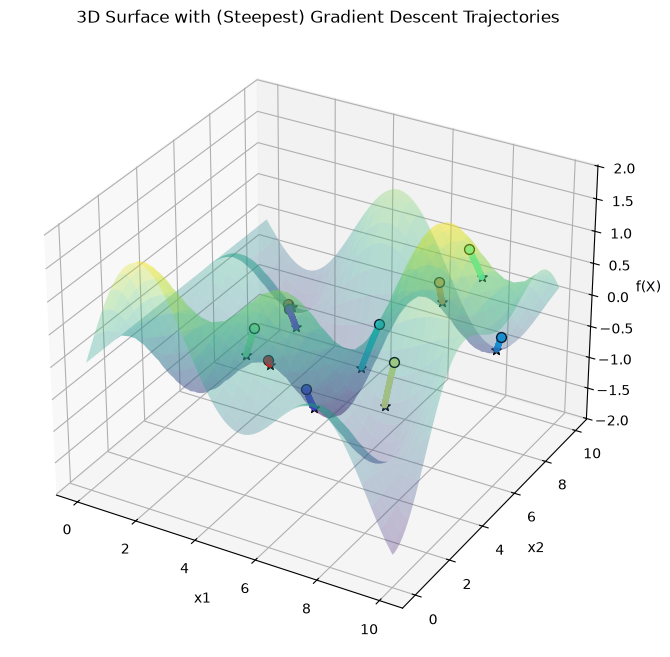

In [14]:
# Convert to array for easier indexing
x_history = torch.stack(x_history, dim=0)  # Shape: (steps+1, points, 2)

# 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
ax.plot_surface(X1, X2, Y, cmap='viridis', edgecolor='none', alpha=0.3)

# Plot trajectories
colors = plt.cm.rainbow(torch.linspace(0, 1, points))

for i in range(points):
    traj_x1 = x_history[:, i, 0]  # x1 coordinates over time
    traj_x2 = x_history[:, i, 1]  # x2 coordinates over time

    # Compute f values for all points in trajectory at once
    traj_points = torch.column_stack([traj_x1, traj_x2])
    traj_y = f(traj_points)
    
    # Plot all points along the trajectory
    ax.scatter(traj_x1, traj_x2, traj_y, color=colors[i], s=10, alpha=0.6)

    # Mark starting point
    ax.scatter(traj_x1[0], traj_x2[0], traj_y[0], color=colors[i], s=50,
               marker='o', edgecolor='black', linewidth=1)
    
    # Mark ending point
    ax.scatter(traj_x1[-1], traj_x2[-1], traj_y[-1], color=colors[i], s=50,
               marker='*', edgecolor='black', linewidth=1)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(X)')
ax.set_title('3D Surface with (Steepest) Gradient Descent Trajectories')
plt.show()

## 4. Gradient descent with momentum

$$g_t = -\eta_t \nabla f(x_{t-1}) + \lambda g_{t-1}$$
$$x_t = x_{t-1} + g_t$$

In [15]:
learning_rate = 1e-3
momentum = 0.9
points = 10  # starting points
steps = 5000

x_0 = torch.rand((points, 2)) * 10

In [16]:
x_history = [x_0.clone()]
x = x_0
g = 0

for _ in range(steps):
    g = -learning_rate * df(x) + momentum * g
    x = x + g
    x_history.append(x.clone())

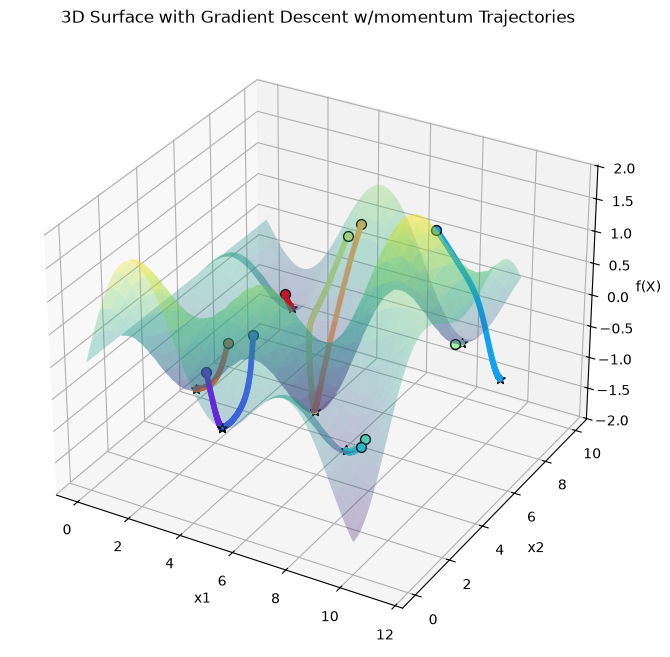

In [17]:
# Convert to array for easier indexing
x_history = torch.stack(x_history, dim=0)  # Shape: (steps+1, points, 2)

# 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
ax.plot_surface(X1, X2, Y, cmap='viridis', edgecolor='none', alpha=0.3)

# Plot trajectories
colors = plt.cm.rainbow(torch.linspace(0, 1, points))

for i in range(points):
    traj_x1 = x_history[:, i, 0]  # x1 coordinates over time
    traj_x2 = x_history[:, i, 1]  # x2 coordinates over time

    # Compute f values for all points in trajectory at once
    traj_points = torch.column_stack([traj_x1, traj_x2])
    traj_y = f(traj_points)
    
    # Plot all points along the trajectory
    ax.scatter(traj_x1, traj_x2, traj_y, color=colors[i], s=10, alpha=0.6)
    
    # Mark starting point
    ax.scatter(traj_x1[0], traj_x2[0], traj_y[0], color=colors[i], s=50,
               marker='o', edgecolor='black', linewidth=1)
    
    # Mark ending point
    ax.scatter(traj_x1[-1], traj_x2[-1], traj_y[-1], color=colors[i], s=50,
               marker='*', edgecolor='black', linewidth=1)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(X)')
ax.set_title('3D Surface with Gradient Descent w/momentum Trajectories')
plt.show()

In [18]:
# EOF